In [2]:
# Cell 1: Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# For BLEU score
# from torchtext.data.metrics import bleu_score
import unicodedata
import re
import random
import time
import math

TEACHER_FORCING_RATIO = 0.5
MAX_LENGTH = 10  # We'll filter sentences longer than this to speed up training
SOS_TOKEN = 0    # Start of Sentence
EOS_TOKEN = 1    # End of Sentence
PAD_TOKEN = 2    # Padding

Using device: cpu


In [3]:
# # Cell 2: Create a toy dataset with simple parallel sentences
# # This simulates English to Swahili-like translation patterns

# # Toy parallel corpus (English -> Target Language)
# parallel_sentences = [
#     # Simple greetings
#     ("hello", "jambo"),
#     ("good morning", "habari ya asubuhi"),
#     ("good evening", "habari ya jioni"),
#     ("how are you", "habari yako"),
#     ("thank you", "asante"),
#     ("welcome", "karibu"),

#     # Simple phrases
#     ("i am fine", "niko sawa"),
#     ("what is your name", "jina lako nani"),
#     ("my name is john", "jina langu ni john"),
#     ("where are you from", "unatoka wapi"),
#     ("i am from kenya", "natoka kenya"),
#     ("i am from tanzania", "natoka tanzania"),

#     # Numbers and basic concepts
#     ("one two three", "moja mbili tatu"),
#     ("i love you", "nakupenda"),
#     ("good night", "usiku mwema"),
#     ("see you tomorrow", "tutaonana kesho"),
#     ("please help me", "tafadhali nisaidie"),
#     ("yes", "ndiyo"),
#     ("no", "hapana"),

#     # Food and daily life
#     ("i want water", "nataka maji"),
#     ("i want food", "nataka chakula"),
#     ("where is the market", "soko liko wapi"),
#     ("how much", "bei gani"),
#     ("very good", "nzuri sana"),

#     # Extended phrases for variety
#     ("the book is red", "kitabu ni nyekundu"),
#     ("the car is fast", "gari ni kasi"),
#     ("i go to school", "naenda shule"),
#     ("she is a teacher", "yeye ni mwalimu"),
#     ("we are learning", "tunajifunza"),
# ]

# # Augment dataset with repetitions and variations
# augmented_data = []
# for _ in range(20):  # Repeat dataset for more training examples
#     for src, tgt in parallel_sentences:
#         augmented_data.append((src, tgt))

# # Shuffle the augmented data
# random.shuffle(augmented_data)

# print(f"Total number of sentence pairs: {len(augmented_data)}")
# print("\nSample translations:")
# for i in range(5):
#     src, tgt = augmented_data[i]
#     print(f"  {src:30} -> {tgt}")



In [4]:

# Helper to download and unzip the data
!wget -O eng-fra.zip https://download.pytorch.org/tutorial/data.zip
!unzip -o eng-fra.zip
!mv data/eng-fra.txt .

# Vocabulary class to map words to indices
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {"<SOS>": SOS_TOKEN, "<EOS>": EOS_TOKEN, "<PAD>": PAD_TOKEN}
        self.word2count = {}
        self.index2word = {SOS_TOKEN: "<SOS>", EOS_TOKEN: "<EOS>", PAD_TOKEN: "<PAD>"}
        self.n_words = 3  # Count SOS, EOS, PAD

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

# Helper functions for text normalization
def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

def normalize_string(s):
    s = unicode_to_ascii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s

# Read and process the data
def read_langs(lang1, lang2, reverse=False):
    print("Reading lines...")
    lines = open('eng-fra.txt', encoding='utf-8').read().strip().split('\n')
    pairs = [[normalize_string(s) for s in l.split('\t')] for l in lines]

    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

# Filter pairs to our MAX_LENGTH constraint
def filter_pair(p):
    return len(p[0].split(' ')) < MAX_LENGTH and \
        len(p[1].split(' ')) < MAX_LENGTH

def filter_pairs(pairs):
    return [p for p in pairs if filter_pair(p)]

def prepare_data(lang1, lang2, reverse=False):
    input_lang, output_lang, pairs = read_langs(lang1, lang2, reverse)
    print(f"Read {len(pairs)} sentence pairs")
    pairs = filter_pairs(pairs)
    print(f"Trimmed to {len(pairs)} sentence pairs (max length {MAX_LENGTH})")
    print("Counting words...")
    for pair in pairs:
        input_lang.add_sentence(pair[0])
        output_lang.add_sentence(pair[1])
    print("Counted words:")
    print(f"{input_lang.name}: {input_lang.n_words}")
    print(f"{output_lang.name}: {output_lang.n_words}")
    return input_lang, output_lang, pairs

# Let's prepare the data: French -> English
input_lang, output_lang, augmented_data = prepare_data('eng', 'fra', True)
print("\nExample pair:")

--2025-10-13 11:58:26--  https://download.pytorch.org/tutorial/data.zip
Resolving download.pytorch.org (download.pytorch.org)... 108.156.60.77, 108.156.60.94, 108.156.60.129, ...
Connecting to download.pytorch.org (download.pytorch.org)|108.156.60.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2882130 (2.7M) [application/zip]
Saving to: ‘eng-fra.zip’

eng-fra.zip         100%[===================>]   2.75M  --.-KB/s    in 0.05s   

2025-10-13 11:58:26 (54.8 MB/s) - ‘eng-fra.zip’ saved [2882130/2882130]

Archive:  eng-fra.zip
   creating: data/
  inflating: data/eng-fra.txt        
   creating: data/names/
  inflating: data/names/Arabic.txt   
  inflating: data/names/Chinese.txt  
  inflating: data/names/Czech.txt    
  inflating: data/names/Dutch.txt    
  inflating: data/names/English.txt  
  inflating: data/names/French.txt   
  inflating: data/names/German.txt   
  inflating: data/names/Greek.txt    
  inflating: data/names/Irish.txt    
  inflating: dat

In [6]:
# Cell 3: Vocabulary building and text processing

class Vocabulary:
    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        self.word_count = Counter()

        # Special tokens
        self.pad_token = '<PAD>'
        self.sos_token = '<SOS>'
        self.eos_token = '<EOS>'
        self.unk_token = '<UNK>'

        # Add special tokens
        for token in [self.pad_token, self.sos_token, self.eos_token, self.unk_token]:
            self.add_word(token)

    def add_word(self, word):
        if word not in self.word2idx:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word
        self.word_count[word] += 1

    def add_sentence(self, sentence):
        for word in sentence.split():
            self.add_word(word)

    def __len__(self):
        return len(self.word2idx)

    def encode(self, sentence):
        tokens = sentence.split()
        indices = [self.word2idx[self.sos_token]]
        for token in tokens:
            indices.append(self.word2idx.get(token, self.word2idx[self.unk_token]))
        indices.append(self.word2idx[self.eos_token])
        return indices

    def decode(self, indices):
        words = []
        for idx in indices:
            if idx == self.word2idx[self.eos_token]:
                break
            if idx not in [self.word2idx[self.pad_token], self.word2idx[self.sos_token]]:
                words.append(self.idx2word[idx])
        return ' '.join(words)

# Build vocabularies
src_vocab = Vocabulary()
tgt_vocab = Vocabulary()

for src, tgt in augmented_data:
    src_vocab.add_sentence(src)
    tgt_vocab.add_sentence(tgt)

print(f"Source vocabulary size: {len(src_vocab)}")
print(f"Target vocabulary size: {len(tgt_vocab)}")
print(f"\nSource vocabulary sample: {list(src_vocab.word2idx.keys())[:10]}")
print(f"Target vocabulary sample: {list(tgt_vocab.word2idx.keys())[:10]}")

Source vocabulary size: 16814
Target vocabulary size: 10026

Source vocabulary sample: ['<PAD>', '<SOS>', '<EOS>', '<UNK>', 'va', '!', 'cours', 'courez', 'ca', 'alors']
Target vocabulary sample: ['<PAD>', '<SOS>', '<EOS>', '<UNK>', 'go', '.', 'run', '!', 'wow', 'fire']


In [7]:
# Cell 4: Dataset class for PyTorch

class TranslationDataset(Dataset):
    def __init__(self, data, src_vocab, tgt_vocab):
        self.data = data
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src, tgt = self.data[idx]
        src_encoded = torch.tensor(self.src_vocab.encode(src), dtype=torch.long)
        tgt_encoded = torch.tensor(self.tgt_vocab.encode(tgt), dtype=torch.long)
        return src_encoded, tgt_encoded

def collate_fn(batch):
    """Custom collate function to pad sequences in a batch"""
    src_batch, tgt_batch = zip(*batch)
    src_batch = pad_sequence(src_batch, batch_first=True, padding_value=0)
    tgt_batch = pad_sequence(tgt_batch, batch_first=True, padding_value=0)
    return src_batch, tgt_batch

# Split data into train and validation sets
train_size = int(0.8 * len(augmented_data))
train_data = augmented_data[:train_size]
val_data = augmented_data[train_size:]

# Create datasets and dataloaders
train_dataset = TranslationDataset(train_data, src_vocab, tgt_vocab)
val_dataset = TranslationDataset(val_data, src_vocab, tgt_vocab)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batch size: {batch_size}")

Training samples: 76136
Validation samples: 19034
Batch size: 32


In [8]:
# Cell 5: Vanilla RNN Encoder

class VanillaRNNEncoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, dropout_p=0.1):
        super(VanillaRNNEncoder, self).__init__()

        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.dropout = nn.Dropout(dropout_p)

        # Vanilla RNN cell - implementing from scratch
        self.rnn_cell = nn.RNNCell(embed_size, hidden_size)

    def forward(self, x, hidden=None):
        """
        Args:
            x: Input tensor of shape (batch_size, seq_len)
            hidden: Initial hidden state
        Returns:
            outputs: All hidden states (batch_size, seq_len, hidden_size)
            hidden: Final hidden state (batch_size, hidden_size)
        """
        batch_size = x.size(0)
        seq_len = x.size(1)

        # Initialize hidden state if not provided
        if hidden is None:
            hidden = torch.zeros(batch_size, self.hidden_size).to(x.device)

        # Embedding
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_size)
        embedded = self.dropout(embedded)

        outputs = []

        # Process sequence step by step (vanilla RNN style)
        for t in range(seq_len):
            # RNN cell computation
            hidden = self.rnn_cell(embedded[:, t, :], hidden)
            hidden = torch.tanh(hidden)  # Apply activation
            outputs.append(hidden.unsqueeze(1))

        outputs = torch.cat(outputs, dim=1)  # (batch_size, seq_len, hidden_size)

        return outputs, hidden

# Test encoder
test_encoder = VanillaRNNEncoder(len(src_vocab), 128, 256)
test_input = torch.randint(0, len(src_vocab), (2, 10))  # batch_size=2, seq_len=10
test_outputs, test_hidden = test_encoder(test_input)
print(f"Encoder outputs shape: {test_outputs.shape}")
print(f"Encoder final hidden shape: {test_hidden.shape}")

Encoder outputs shape: torch.Size([2, 10, 256])
Encoder final hidden shape: torch.Size([2, 256])


In [9]:
# Cell 6: Vanilla RNN Decoder

class VanillaRNNDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, dropout_p=0.1):
        super(VanillaRNNDecoder, self).__init__()

        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.dropout = nn.Dropout(dropout_p)

        # Vanilla RNN cell
        self.rnn_cell = nn.RNNCell(embed_size, hidden_size)

        # Output projection layer
        self.output_projection = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, encoder_hidden, encoder_outputs=None):
        """
        Args:
            x: Target input tensor (batch_size, seq_len)
            encoder_hidden: Final hidden state from encoder
            encoder_outputs: Not used in vanilla RNN (kept for compatibility)
        Returns:
            outputs: Predictions (batch_size, seq_len, vocab_size)
        """
        batch_size = x.size(0)
        seq_len = x.size(1)

        # Initialize decoder hidden state with encoder's final hidden state
        hidden = encoder_hidden

        # Embedding
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_size)
        embedded = self.dropout(embedded)

        outputs = []

        # Decode step by step
        for t in range(seq_len):
            # RNN cell computation
            hidden = self.rnn_cell(embedded[:, t, :], hidden)
            hidden = torch.tanh(hidden)

            # Project to vocabulary size
            output = self.output_projection(hidden)
            outputs.append(output.unsqueeze(1))

        outputs = torch.cat(outputs, dim=1)  # (batch_size, seq_len, vocab_size)

        return outputs

# Test decoder
test_decoder = VanillaRNNDecoder(len(tgt_vocab), 128, 256)
test_target = torch.randint(0, len(tgt_vocab), (2, 8))  # batch_size=2, seq_len=8
test_decoder_outputs = test_decoder(test_target, test_hidden)
print(f"Decoder outputs shape: {test_decoder_outputs.shape}")

Decoder outputs shape: torch.Size([2, 8, 10026])


In [10]:
# Cell 7: Complete Vanilla RNN Seq2Seq Model

class VanillaSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(VanillaSeq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        """
        Args:
            src: Source sequences (batch_size, src_seq_len)
            tgt: Target sequences (batch_size, tgt_seq_len)
        Returns:
            outputs: Predictions (batch_size, tgt_seq_len, vocab_size)
        """
        # Encode source sequence
        encoder_outputs, encoder_hidden = self.encoder(src)

        # Decode to target sequence
        outputs = self.decoder(tgt, encoder_hidden)

        return outputs

    def translate(self, src, max_length=50):
        """Translate a source sentence (inference mode)"""
        self.eval()
        with torch.no_grad():
            # Encode source
            encoder_outputs, encoder_hidden = self.encoder(src)

            batch_size = src.size(0)
            device = src.device

            # Start with SOS token
            decoder_input = torch.tensor([[1]]).to(device)  # SOS token index
            hidden = encoder_hidden

            translated = []

            for _ in range(max_length):
                # Decode one step
                embedded = self.decoder.embedding(decoder_input)
                hidden = self.decoder.rnn_cell(embedded.squeeze(1), hidden)
                hidden = torch.tanh(hidden)
                output = self.decoder.output_projection(hidden)

                # Get predicted word
                predicted = output.argmax(dim=-1)
                translated.append(predicted.item())

                # Stop if EOS token is predicted
                if predicted.item() == 2:  # EOS token index
                    break

                # Use predicted word as next input
                decoder_input = predicted.unsqueeze(0)

            return translated

In [11]:
# Cell 8: Bahdanau Attention Mechanism

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()

        # Attention parameters
        self.Wa = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Ua = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Va = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, query, keys):
        """
        Calculate attention weights and context vector

        Args:
            query: Decoder hidden state (batch_size, hidden_size)
            keys: Encoder outputs (batch_size, seq_len, hidden_size)
        Returns:
            context: Weighted sum of encoder outputs (batch_size, hidden_size)
            attention_weights: Attention distribution (batch_size, seq_len)
        """
        # Add time dimension to query for broadcasting
        query = query.unsqueeze(1)  # (batch_size, 1, hidden_size)

        # Calculate attention scores
        scores = self.Va(torch.tanh(
            self.Wa(query) + self.Ua(keys)
        ))  # (batch_size, seq_len, 1)

        # Convert scores to probabilities
        attention_weights = F.softmax(scores.squeeze(-1), dim=-1)  # (batch_size, seq_len)

        # Calculate context vector (weighted sum of encoder outputs)
        context = torch.bmm(attention_weights.unsqueeze(1), keys)  # (batch_size, 1, hidden_size)
        context = context.squeeze(1)  # (batch_size, hidden_size)

        return context, attention_weights

# Test attention
test_attention = BahdanauAttention(256)
test_query = torch.randn(2, 256)  # batch_size=2, hidden_size=256
test_keys = torch.randn(2, 10, 256)  # batch_size=2, seq_len=10, hidden_size=256
test_context, test_weights = test_attention(test_query, test_keys)
print(f"Context shape: {test_context.shape}")
print(f"Attention weights shape: {test_weights.shape}")
print(f"Attention weights sum: {test_weights.sum(dim=-1)}")  # Should be 1.0 for each batch

Context shape: torch.Size([2, 256])
Attention weights shape: torch.Size([2, 10])
Attention weights sum: tensor([1., 1.], grad_fn=<SumBackward1>)


In [12]:
# Cell 9: RNN Decoder with Attention

class AttentionRNNDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, dropout_p=0.1):
        super(AttentionRNNDecoder, self).__init__()

        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.dropout = nn.Dropout(dropout_p)

        # Attention mechanism
        self.attention = BahdanauAttention(hidden_size)

        # RNN cell (input is concatenation of embedding and context)
        self.rnn_cell = nn.RNNCell(embed_size + hidden_size, hidden_size)

        # Output projection (input is concatenation of hidden and context)
        self.output_projection = nn.Linear(hidden_size + hidden_size, vocab_size)

    def forward(self, x, encoder_hidden, encoder_outputs):
        """
        Args:
            x: Target input tensor (batch_size, seq_len)
            encoder_hidden: Final hidden state from encoder
            encoder_outputs: All encoder hidden states for attention
        Returns:
            outputs: Predictions (batch_size, seq_len, vocab_size)
            attention_weights: Attention weights for visualization
        """
        batch_size = x.size(0)
        seq_len = x.size(1)

        # Initialize decoder hidden state
        hidden = encoder_hidden

        # Embedding
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)

        outputs = []
        attention_weights_all = []

        for t in range(seq_len):
            # Calculate attention
            context, attention_weights = self.attention(hidden, encoder_outputs)
            attention_weights_all.append(attention_weights.unsqueeze(1))

            # Concatenate embedding and context
            rnn_input = torch.cat([embedded[:, t, :], context], dim=-1)

            # RNN cell computation
            hidden = self.rnn_cell(rnn_input, hidden)
            hidden = torch.tanh(hidden)

            # Concatenate hidden state and context for output projection
            output_input = torch.cat([hidden, context], dim=-1)
            output = self.output_projection(output_input)
            outputs.append(output.unsqueeze(1))

        outputs = torch.cat(outputs, dim=1)
        attention_weights_all = torch.cat(attention_weights_all, dim=1)

        return outputs, attention_weights_all

In [13]:
# Cell 10: Complete Attention-based Seq2Seq Model

class AttentionSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(AttentionSeq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        """
        Args:
            src: Source sequences (batch_size, src_seq_len)
            tgt: Target sequences (batch_size, tgt_seq_len)
        Returns:
            outputs: Predictions (batch_size, tgt_seq_len, vocab_size)
            attention_weights: Attention weights for visualization
        """
        # Encode source sequence
        encoder_outputs, encoder_hidden = self.encoder(src)

        # Decode with attention
        outputs, attention_weights = self.decoder(tgt, encoder_hidden, encoder_outputs)

        return outputs, attention_weights

    def translate(self, src, max_length=50):
        """Translate a source sentence with attention (inference mode)"""
        self.eval()
        with torch.no_grad():
            # Encode source
            encoder_outputs, encoder_hidden = self.encoder(src)

            device = src.device

            # Start with SOS token
            decoder_input = torch.tensor([[1]]).to(device)
            hidden = encoder_hidden

            translated = []
            attention_weights_all = []

            for _ in range(max_length):
                # Get embedding
                embedded = self.decoder.embedding(decoder_input)

                # Calculate attention
                context, attention_weights = self.decoder.attention(hidden, encoder_outputs)
                attention_weights_all.append(attention_weights)

                # RNN computation
                rnn_input = torch.cat([embedded.squeeze(1), context], dim=-1)
                hidden = self.decoder.rnn_cell(rnn_input, hidden)
                hidden = torch.tanh(hidden)

                # Output projection
                output_input = torch.cat([hidden, context], dim=-1)
                output = self.decoder.output_projection(output_input)

                # Get predicted word
                predicted = output.argmax(dim=-1)
                translated.append(predicted.item())

                # Stop if EOS token
                if predicted.item() == 2:
                    break

                decoder_input = predicted.unsqueeze(0)

            return translated, torch.stack(attention_weights_all)

In [14]:
# Cell 11: Training and evaluation functions

def train_epoch(model, data_loader, optimizer, criterion, device, with_attention=False):
    """Train for one epoch"""
    model.train()
    total_loss = 0

    progress_bar = tqdm(data_loader, desc='Training')

    for src, tgt in progress_bar:
        src = src.to(device)
        tgt = tgt.to(device)

        # Prepare target input and output
        tgt_input = tgt[:, :-1]  # Remove last token for input
        tgt_output = tgt[:, 1:]  # Remove first token (SOS) for output

        optimizer.zero_grad()

        # Forward pass
        if with_attention:
            outputs, _ = model(src, tgt_input)
        else:
            outputs = model(src, tgt_input)

        # Reshape for loss calculation
        outputs = outputs.reshape(-1, outputs.size(-1))
        tgt_output = tgt_output.reshape(-1)

        # Calculate loss
        loss = criterion(outputs, tgt_output)

        # Backward pass
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    return total_loss / len(data_loader)

def evaluate(model, data_loader, criterion, device, with_attention=False):
    """Evaluate the model"""
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, tgt in data_loader:
            src = src.to(device)
            tgt = tgt.to(device)

            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            if with_attention:
                outputs, _ = model(src, tgt_input)
            else:
                outputs = model(src, tgt_input)

            outputs = outputs.reshape(-1, outputs.size(-1))
            tgt_output = tgt_output.reshape(-1)

            loss = criterion(outputs, tgt_output)
            total_loss += loss.item()

    return total_loss / len(data_loader)

def calculate_perplexity(loss):
    """Calculate perplexity from loss"""
    return np.exp(loss)

In [15]:
# Cell 12: Initialize models

# Model hyperparameters
embed_size = 128
hidden_size = 256
dropout_p = 0.1
learning_rate = 0.001
num_epochs = 10

# Initialize Vanilla RNN model
vanilla_encoder = VanillaRNNEncoder(len(src_vocab), embed_size, hidden_size, dropout_p).to(device)
vanilla_decoder = VanillaRNNDecoder(len(tgt_vocab), embed_size, hidden_size, dropout_p).to(device)
vanilla_model = VanillaSeq2Seq(vanilla_encoder, vanilla_decoder).to(device)

# Initialize Attention model
attention_encoder = VanillaRNNEncoder(len(src_vocab), embed_size, hidden_size, dropout_p).to(device)
attention_decoder = AttentionRNNDecoder(len(tgt_vocab), embed_size, hidden_size, dropout_p).to(device)
attention_model = AttentionSeq2Seq(attention_encoder, attention_decoder).to(device)

# Loss function (ignore padding token)
criterion = nn.CrossEntropyLoss(ignore_index=0)

# Optimizers
vanilla_optimizer = optim.Adam(vanilla_model.parameters(), lr=learning_rate)
attention_optimizer = optim.Adam(attention_model.parameters(), lr=learning_rate)

print("Models initialized successfully!")
print(f"Vanilla model parameters: {sum(p.numel() for p in vanilla_model.parameters()):,}")
print(f"Attention model parameters: {sum(p.numel() for p in attention_model.parameters()):,}")

Models initialized successfully!
Vanilla model parameters: 6,209,834
Attention model parameters: 8,973,354


In [ ]:
# Cell 13: Train both models

# Training history
vanilla_train_losses = []
vanilla_val_losses = []
attention_train_losses = []
attention_val_losses = []

print("=" * 50)
print("Training Vanilla RNN Model")
print("=" * 50)

for epoch in range(num_epochs):
    # Train vanilla model
    train_loss = train_epoch(vanilla_model, train_loader, vanilla_optimizer, criterion, device, with_attention=False)
    val_loss = evaluate(vanilla_model, val_loader, criterion, device, with_attention=False)

    vanilla_train_losses.append(train_loss)
    vanilla_val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        train_ppl = calculate_perplexity(train_loss)
        val_ppl = calculate_perplexity(val_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train PPL: {train_ppl:.2f} | Val PPL: {val_ppl:.2f}")

print("\n" + "=" * 50)
print("Training Attention RNN Model")
print("=" * 50)

for epoch in range(num_epochs):
    # Train attention model
    train_loss = train_epoch(attention_model, train_loader, attention_optimizer, criterion, device, with_attention=True)
    val_loss = evaluate(attention_model, val_loader, criterion, device, with_attention=True)

    attention_train_losses.append(train_loss)
    attention_val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        train_ppl = calculate_perplexity(train_loss)
        val_ppl = calculate_perplexity(val_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train PPL: {train_ppl:.2f} | Val PPL: {val_ppl:.2f}")

Training Vanilla RNN Model


Training:  47%|████▋     | 1119/2380 [05:00<05:47,  3.63it/s, loss=2.55]

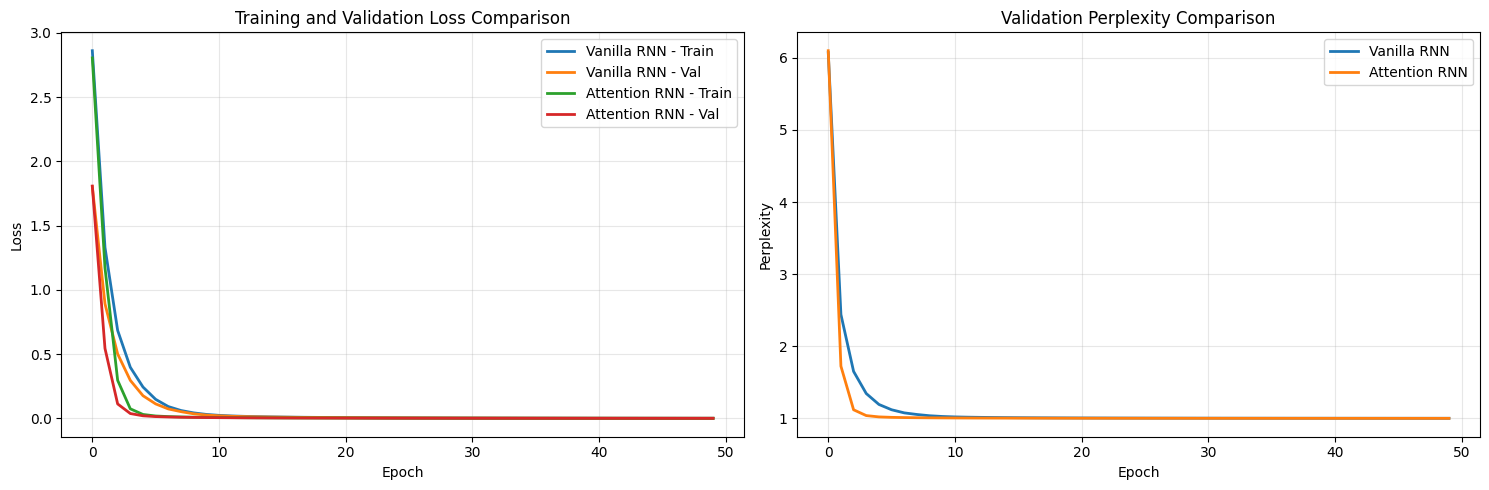


Final Performance Comparison:
----------------------------------------
Vanilla RNN - Final Val Loss: 0.0013 | Final Val PPL: 1.00
Attention RNN - Final Val Loss: 0.0006 | Final Val PPL: 1.00
Perplexity Improvement with Attention: 0.1%


In [ ]:
# Cell 14: Plot training curves

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss comparison
axes[0].plot(vanilla_train_losses, label='Vanilla RNN - Train', linewidth=2)
axes[0].plot(vanilla_val_losses, label='Vanilla RNN - Val', linewidth=2)
axes[0].plot(attention_train_losses, label='Attention RNN - Train', linewidth=2)
axes[0].plot(attention_val_losses, label='Attention RNN - Val', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perplexity comparison
vanilla_train_ppl = [calculate_perplexity(loss) for loss in vanilla_train_losses]
vanilla_val_ppl = [calculate_perplexity(loss) for loss in vanilla_val_losses]
attention_train_ppl = [calculate_perplexity(loss) for loss in attention_train_losses]
attention_val_ppl = [calculate_perplexity(loss) for loss in attention_val_losses]

axes[1].plot(vanilla_val_ppl, label='Vanilla RNN', linewidth=2)
axes[1].plot(attention_val_ppl, label='Attention RNN', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Validation Perplexity Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final performance
print("\nFinal Performance Comparison:")
print("-" * 40)
print(f"Vanilla RNN - Final Val Loss: {vanilla_val_losses[-1]:.4f} | Final Val PPL: {vanilla_val_ppl[-1]:.2f}")
print(f"Attention RNN - Final Val Loss: {attention_val_losses[-1]:.4f} | Final Val PPL: {attention_val_ppl[-1]:.2f}")
improvement = ((vanilla_val_ppl[-1] - attention_val_ppl[-1]) / vanilla_val_ppl[-1]) * 100
print(f"Perplexity Improvement with Attention: {improvement:.1f}%")

In [ ]:
# Cell 15: Translation examples and attention visualization

def translate_and_visualize(model, sentence, src_vocab, tgt_vocab, with_attention=False):
    """Translate a sentence and visualize attention if applicable"""

    # Encode source sentence
    src_encoded = torch.tensor([src_vocab.encode(sentence)]).to(device)

    if with_attention:
        # Get translation with attention weights
        translated_indices, attention_weights = model.translate(src_encoded)
        attention_weights = attention_weights.squeeze(1).cpu().numpy()
    else:
        # Get translation without attention
        translated_indices = model.translate(src_encoded)
        attention_weights = None

    # Decode translation
    translated = tgt_vocab.decode(translated_indices)

    return translated, attention_weights

# Test sentences
test_sentences = [
    "hello",
    "how are you",
    "i love you",
    "good morning",
    "where is the market"
]

print("=" * 60)
print("Translation Comparison")
print("=" * 60)

for sentence in test_sentences:
    print(f"\nSource: {sentence}")

    # Vanilla RNN translation
    vanilla_translation, _ = translate_and_visualize(vanilla_model, sentence, src_vocab, tgt_vocab, with_attention=False)
    print(f"Vanilla RNN: {vanilla_translation}")

    # Attention RNN translation
    attention_translation, attention_weights = translate_and_visualize(attention_model, sentence, src_vocab, tgt_vocab, with_attention=True)
    print(f"Attention RNN: {attention_translation}")

    # Ground truth (if available in training data)
    for src, tgt in parallel_sentences:
        if src == sentence:
            print(f"Ground Truth: {tgt}")
            break

Translation Comparison

Source: hello
Vanilla RNN: jina lako nani
Attention RNN: jambo jambo
Ground Truth: jambo

Source: how are you
Vanilla RNN: ndiyo
Attention RNN: habari yako
Ground Truth: habari yako

Source: i love you
Vanilla RNN: natoka tanzania
Attention RNN: nakupenda
Ground Truth: nakupenda

Source: good morning
Vanilla RNN: jina langu ni john
Attention RNN: habari ya asubuhi
Ground Truth: habari ya asubuhi

Source: where is the market
Vanilla RNN: soko liko wapi
Attention RNN: soko liko wapi
Ground Truth: soko liko wapi



Visualizing attention for: 'how are you'


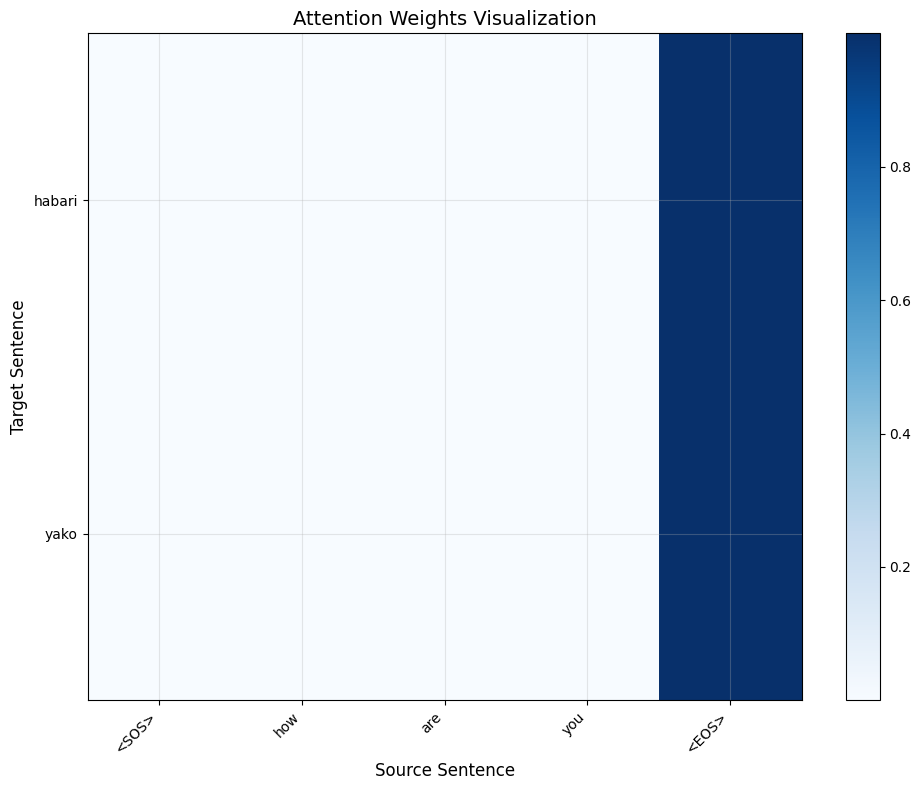


Visualizing attention for: 'where is the market'


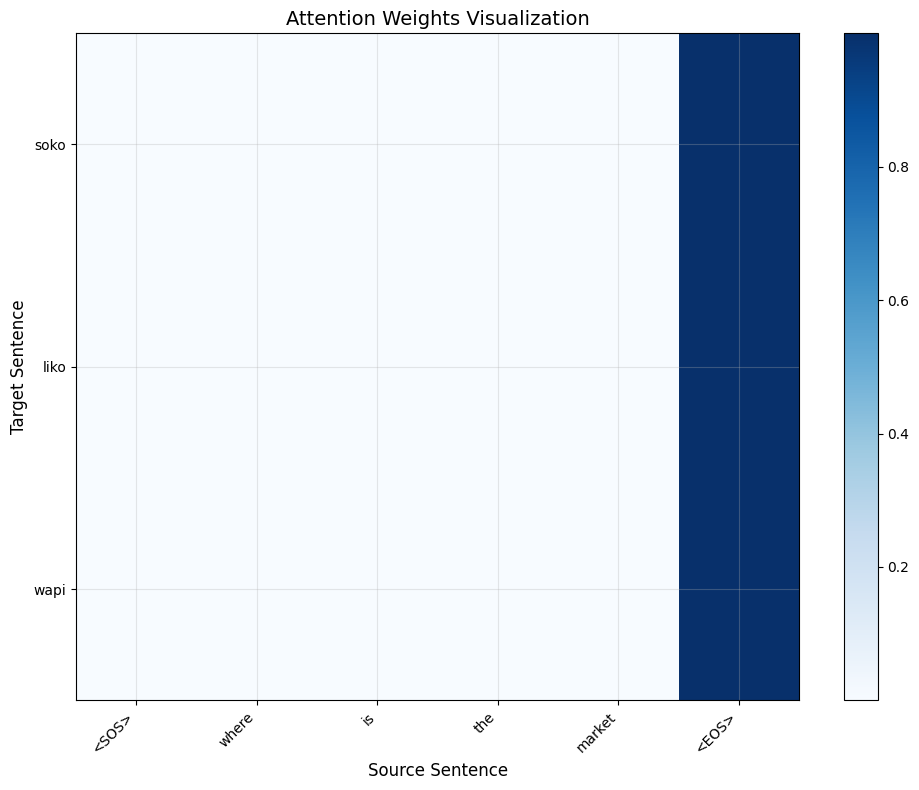

In [ ]:
# Cell 16: Visualize attention weights

def plot_attention(sentence, translation, attention_weights, src_vocab):
    """Plot attention heatmap"""

    # Process source and target sentences
    src_tokens = ['<SOS>'] + sentence.split() + ['<EOS>']
    tgt_tokens = translation.split() if translation else ['<EOS>']

    # Adjust attention weights size
    attention_weights = attention_weights[:len(tgt_tokens), :len(src_tokens)]

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot heatmap
    im = ax.imshow(attention_weights, cmap='Blues', aspect='auto')

    # Set ticks and labels
    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right')
    ax.set_yticklabels(tgt_tokens)

    # Labels
    ax.set_xlabel('Source Sentence', fontsize=12)
    ax.set_ylabel('Target Sentence', fontsize=12)
    ax.set_title('Attention Weights Visualization', fontsize=14)

    # Add colorbar
    plt.colorbar(im, ax=ax)

    # Add grid
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Visualize attention for selected sentences
sentences_to_visualize = ["how are you", "where is the market"]

for sentence in sentences_to_visualize:
    print(f"\nVisualizing attention for: '{sentence}'")

    # Get translation with attention
    attention_translation, attention_weights = translate_and_visualize(
        attention_model, sentence, src_vocab, tgt_vocab, with_attention=True
    )

    # Plot attention
    if attention_weights is not None:
        plot_attention(sentence, attention_translation, attention_weights, src_vocab)

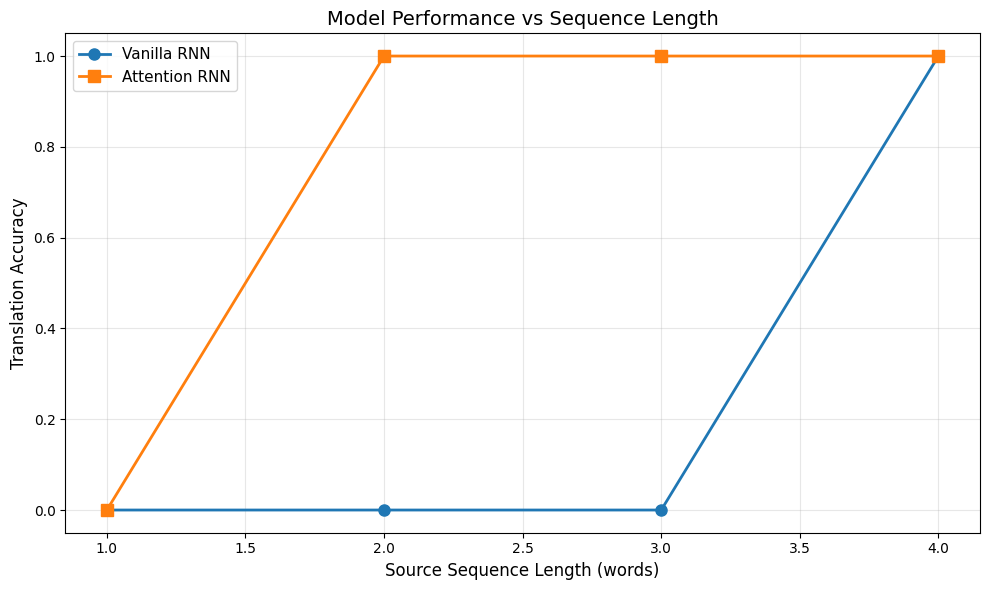


Performance by Sequence Length:
----------------------------------------
Length 1: Vanilla=0.00%, Attention=0.00%
Length 2: Vanilla=0.00%, Attention=100.00%
Length 3: Vanilla=0.00%, Attention=100.00%
Length 4: Vanilla=100.00%, Attention=100.00%


In [ ]:
# Cell 17: Analyze model behavior with sequence length

def analyze_sequence_length_performance(vanilla_model, attention_model, val_data, src_vocab, tgt_vocab):
    """Analyze how models perform with different sequence lengths"""

    # Group validation data by source sequence length
    length_groups = {}
    for src, tgt in val_data:
        src_len = len(src.split())
        if src_len not in length_groups:
            length_groups[src_len] = []
        length_groups[src_len].append((src, tgt))

    # Calculate accuracy for each length group
    vanilla_accuracies = {}
    attention_accuracies = {}

    for length, sentences in length_groups.items():
        vanilla_correct = 0
        attention_correct = 0

        for src, tgt_true in sentences:
            # Vanilla RNN
            vanilla_trans, _ = translate_and_visualize(vanilla_model, src, src_vocab, tgt_vocab, with_attention=False)
            if vanilla_trans.strip() == tgt_true.strip():
                vanilla_correct += 1

            # Attention RNN
            attention_trans, _ = translate_and_visualize(attention_model, src, src_vocab, tgt_vocab, with_attention=True)
            if attention_trans.strip() == tgt_true.strip():
                attention_correct += 1

        if sentences:
            vanilla_accuracies[length] = vanilla_correct / len(sentences)
            attention_accuracies[length] = attention_correct / len(sentences)

    return vanilla_accuracies, attention_accuracies

# Analyze performance
vanilla_acc, attention_acc = analyze_sequence_length_performance(
    vanilla_model, attention_model, val_data, src_vocab, tgt_vocab
)

# Plot results
lengths = sorted(vanilla_acc.keys())
vanilla_scores = [vanilla_acc[l] for l in lengths]
attention_scores = [attention_acc[l] for l in lengths]

plt.figure(figsize=(10, 6))
plt.plot(lengths, vanilla_scores, 'o-', label='Vanilla RNN', linewidth=2, markersize=8)
plt.plot(lengths, attention_scores, 's-', label='Attention RNN', linewidth=2, markersize=8)
plt.xlabel('Source Sequence Length (words)', fontsize=12)
plt.ylabel('Translation Accuracy', fontsize=12)
plt.title('Model Performance vs Sequence Length', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print detailed comparison
print("\nPerformance by Sequence Length:")
print("-" * 40)
for length in lengths:
    print(f"Length {length}: Vanilla={vanilla_acc[length]:.2%}, Attention={attention_acc[length]:.2%}")

In [ ]:
# Cell 19: Bridge to ASR - Key considerations

print("=" * 70)
print("TRANSITIONING TO AUTOMATIC SPEECH RECOGNITION (ASR)")
print("=" * 70)

print("""
Key Parallels Between Machine Translation and ASR:
---------------------------------------------------
1. SEQUENCE-TO-SEQUENCE NATURE
   - MT: Text sequence → Text sequence
   - ASR: Audio sequence → Text sequence

2. ALIGNMENT PROBLEM
   - MT: Word-to-word alignment across languages
   - ASR: Audio frame to phoneme/character alignment

3. VARIABLE LENGTH SEQUENCES
   - MT: Different sentence lengths in source/target
   - ASR: Variable duration speech to variable length text

Key Modifications Needed for ASR:
---------------------------------
""")

# Pseudo-code for ASR modifications
asr_modifications = """
class AudioRNNEncoder(nn.Module):
    '''Encoder for audio features instead of text embeddings'''
    def __init__(self, feature_dim, hidden_size):
        # feature_dim: 13 for MFCC, 40 for mel-spectrogram, etc.
        super().__init__()
        self.rnn_cell = nn.RNNCell(feature_dim, hidden_size)
        # No embedding layer needed - direct audio features

    def forward(self, audio_features):
        # audio_features: (batch_size, time_steps, feature_dim)
        # Process continuous features instead of discrete tokens
        pass

class CTCLoss:
    '''Connectionist Temporal Classification for ASR'''
    # Handles alignment without explicit frame-to-text mapping
    pass

class BeamSearchDecoder:
    '''Improved decoding for ASR'''
    # Better than greedy decoding for speech recognition
    pass
"""

print(asr_modifications)

print("""
Data Preprocessing for ASR:
---------------------------
1. Audio Feature Extraction:
   - MFCC (Mel-frequency cepstral coefficients)
   - Mel-spectrograms
   - Raw waveform (for end-to-end models)

2. Text Processing:
   - Character-level tokenization (common for ASR)
   - Phoneme representation
   - Subword units (BPE)

3. Data Augmentation:
   - Speed perturbation
   - Volume perturbation
   - Noise addition
   - SpecAugment

Expected Challenges in ASR:
---------------------------
1. Much longer sequences (100s of frames vs 10s of words)
2. Noisier input signal
3. Speaker variability
4. Need for larger models and more data
5. Computational requirements higher
""")

TRANSITIONING TO AUTOMATIC SPEECH RECOGNITION (ASR)

Key Parallels Between Machine Translation and ASR:
---------------------------------------------------
1. SEQUENCE-TO-SEQUENCE NATURE
   - MT: Text sequence → Text sequence
   - ASR: Audio sequence → Text sequence

2. ALIGNMENT PROBLEM
   - MT: Word-to-word alignment across languages
   - ASR: Audio frame to phoneme/character alignment

3. VARIABLE LENGTH SEQUENCES
   - MT: Different sentence lengths in source/target
   - ASR: Variable duration speech to variable length text

Key Modifications Needed for ASR:
---------------------------------


class AudioRNNEncoder(nn.Module):
    '''Encoder for audio features instead of text embeddings'''
    def __init__(self, feature_dim, hidden_size):
        # feature_dim: 13 for MFCC, 40 for mel-spectrogram, etc.
        super().__init__()
        self.rnn_cell = nn.RNNCell(feature_dim, hidden_size)
        # No embedding layer needed - direct audio features
        
    def forward(self, audi

In [ ]:
# Cell 20: Next steps and recommendations

print("=" * 70)
print("RECOMMENDED NEXT STEPS")
print("=" * 70)

next_steps = """
1. IMMEDIATE NEXT STEPS:
   ✓ Experiment with different hyperparameters
   ✓ Try different attention mechanisms (Luong attention)
   ✓ Implement beam search for better decoding
   ✓ Add regularization techniques (dropout, weight decay)

2. DATASET PREPARATION FOR ASR:
   ✓ Download African speech datasets (e.g., from Common Voice)
   ✓ Learn audio preprocessing with librosa/torchaudio
   ✓ Create data loaders for audio-text pairs
   ✓ Implement feature extraction pipeline

3. MODEL ADAPTATIONS:
   ✓ Modify encoder for audio features
   ✓ Implement CTC loss or attention-based loss
   ✓ Add beam search decoder
   ✓ Consider hierarchical attention for long sequences

4. PERFORMANCE OPTIMIZATION:
   ✓ Implement gradient accumulation for larger effective batch sizes
   ✓ Use mixed precision training
   ✓ Implement checkpointing for long training runs
   ✓ Consider model pruning for deployment

5. EVALUATION METRICS FOR ASR:
   ✓ Word Error Rate (WER)
   ✓ Character Error Rate (CER)
   ✓ Real-time factor (RTF)
   ✓ Perplexity on language model

6. ADVANCED TECHNIQUES TO EXPLORE:
   ✓ Multi-head attention
   ✓ Transformer architecture (self-attention)
   ✓ Joint CTC-Attention training
   ✓ Language model integration
"""

print(next_steps)

# Save models for future use
torch.save({
    'vanilla_model_state': vanilla_model.state_dict(),
    'attention_model_state': attention_model.state_dict(),
    'src_vocab': src_vocab,
    'tgt_vocab': tgt_vocab,
    'config': {
        'embed_size': embed_size,
        'hidden_size': hidden_size,
        'dropout_p': dropout_p
    }
}, 'translation_models.pth')

print("\nModels saved successfully! Ready for ASR implementation phase.")